# Sugarcane Leaf Disease Detection

## Import Required Libraries

In [1]:
!pip install git+https://github.com/jacobgil/pytorch-grad-cam.git
!pip install lime
!pip install timm -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
import os
import h5py
import timm
from tqdm import tqdm
import torch.amp as amp
from collections import Counter

  Cloning https://github.com/jacobgil/pytorch-grad-cam.git to /tmp/pip-req-build-t6wgmabb
  Running command git clone --filter=blob:none --quiet https://github.com/jacobgil/pytorch-grad-cam.git /tmp/pip-req-build-t6wgmabb
  Resolved https://github.com/jacobgil/pytorch-grad-cam.git to commit 084273b3f30b54ad0c64cf8020a4337d979a66e0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.9 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=48284 sha256=bafbcc7275186d5e7a97cef1a7a1a14ba7f0fa7441f07d13619db9415cdc1916
  Stored in directory: /tmp/pip-ephem-wheel-cache-dqhoqc4e/wheels/69/29/f7/3abdb24031a22af044df15784c8a00f56b6e24f5924e33d0e8
Successfully built grad-cam
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successf

## Load and Prepare the Dataset
All 3 models use 224×224.

In [2]:
# Define transformations — 224x224 for ALL models
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset
dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/mahfuzahmed17/sugarcane-leaf-image-dataset/Sugarcane Leaf Image",
    transform=transform_train
)

train_size = int(0.7 * len(dataset))
val_size   = int(0.2 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Apply test transformation to validation and test sets
val_dataset.dataset.transform  = transform_test
test_dataset.dataset.transform = transform_test

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

class_names = dataset.classes
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

Classes (14): ['Banded Chlorosis', 'Brown Spot', 'BrownRust', 'Dried Leaves', 'Grassy shoot', 'Healthy Leaves', 'Mosaic', 'Pokkah Boeng', 'RedRot', 'Rust', 'Sett Rot', 'Viral Disease', 'Yellow Leaf', 'smut']


## Visualize Example Images for Each Class
Displaying all 14 classes in two rows of 7.

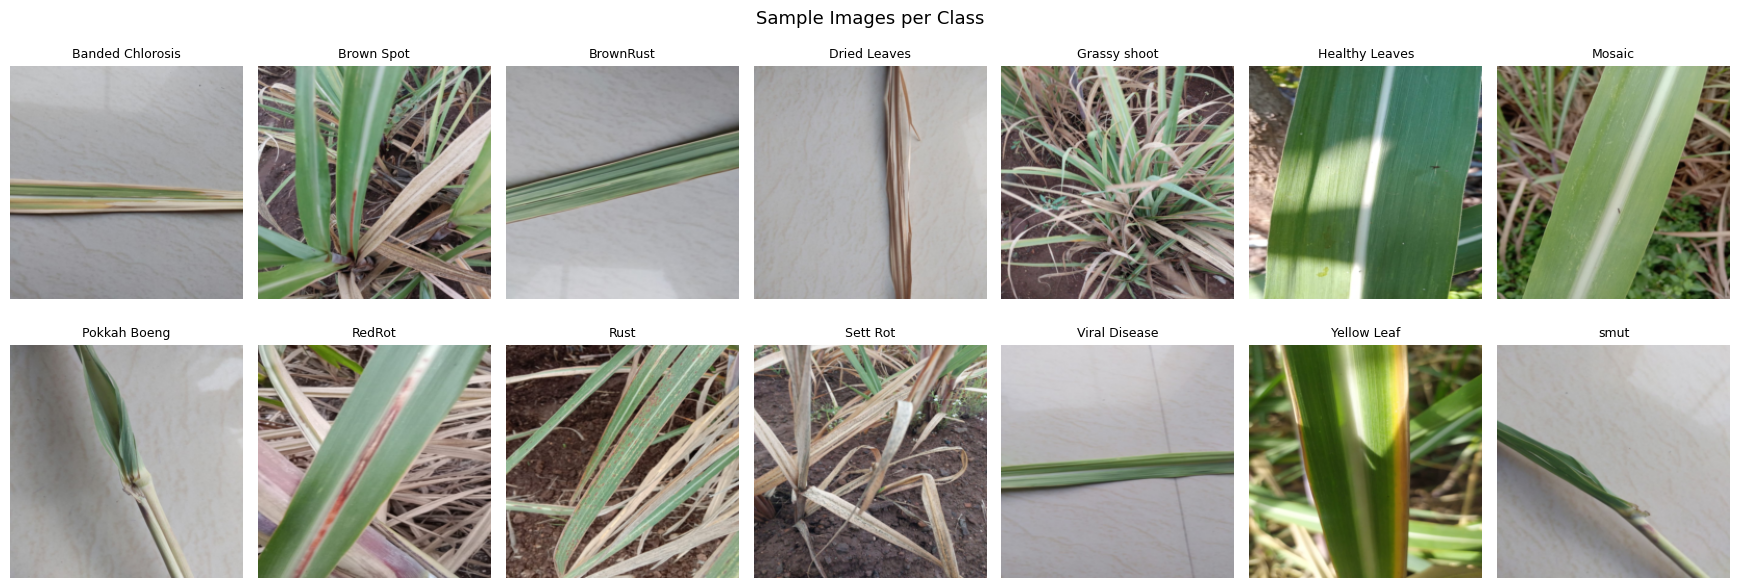

In [3]:
num_cols = 7
num_rows = (num_classes + num_cols - 1) // num_cols

fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2.5, num_rows * 3))
axs = axs.flatten()

collected = {}
for images, labels in train_loader:
    for img, label in zip(images, labels):
        label_idx = label.item()
        if label_idx not in collected:
            collected[label_idx] = img
        if len(collected) == num_classes:
            break
    if len(collected) == num_classes:
        break

for idx in range(num_classes):
    img = collected[idx]
    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np * 0.5) + 0.5
    axs[idx].imshow(np.clip(img_np, 0, 1))
    axs[idx].set_title(class_names[idx], fontsize=9, wrap=True)
    axs[idx].axis('off')

for idx in range(num_classes, len(axs)):
    axs[idx].axis('off')

plt.tight_layout()
plt.suptitle("Sample Images per Class", fontsize=13, y=1.02)
plt.show()

## Class Weights (CW) — For Imbalanced Dataset Balancing
Compute class weights from training data. Applied via `CrossEntropyLoss(weight=class_weights)` in all models.

In [4]:
# Count samples per class in training set
train_labels = [dataset.targets[i] for i in train_dataset.indices]
class_counts = Counter(train_labels)
total_samples = len(train_labels)

# Class weight formula: total / (num_classes * count_per_class)
class_weights = torch.tensor(
    [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)],
    dtype=torch.float
).to('cuda')

print("Class Weights:")
for i, (name, w) in enumerate(zip(class_names, class_weights)):
    print(f"  {name}: {w.item():.4f}  (count: {class_counts[i]})")

Class Weights:
  Banded Chlorosis: 1.4348  (count: 323)
  Brown Spot: 0.3859  (count: 1201)
  BrownRust: 2.1656  (count: 214)
  Dried Leaves: 1.9229  (count: 241)
  Grassy shoot: 1.9071  (count: 243)
  Healthy Leaves: 0.7086  (count: 654)
  Mosaic: 1.4348  (count: 323)
  Pokkah Boeng: 2.2497  (count: 206)
  RedRot: 1.2697  (count: 365)
  Rust: 1.3203  (count: 351)
  Sett Rot: 0.9736  (count: 476)
  Viral Disease: 0.9966  (count: 465)
  Yellow Leaf: 0.3852  (count: 1203)
  smut: 2.0782  (count: 223)


## Attention Modules — SE Block and CBAM Block

**SE (Squeeze-and-Excitation):** Channel attention only — learns *which* feature channels are important.

**CBAM (Convolutional Block Attention Module):** Channel attention + Spatial attention — learns *which channels* AND *where* in the image to focus.

In [5]:
# ── SE Block ──────────────────────────────────────────────────────────────────
class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block — channel attention only."""
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        # Squeeze: global average pooling
        y = self.avg_pool(x).view(b, c)
        # Excitation: two FC layers with sigmoid
        y = self.fc(y).view(b, c, 1, 1)
        # Scale: recalibrate channel features
        return x * y.expand_as(x)


# ── CBAM Block ────────────────────────────────────────────────────────────────
class ChannelAttention(nn.Module):
    """Channel attention sub-module of CBAM."""
    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        scale = self.sigmoid(avg_out + max_out).unsqueeze(2).unsqueeze(3)
        return x * scale.expand_as(x)


class SpatialAttention(nn.Module):
    """Spatial attention sub-module of CBAM."""
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size,
                              padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        scale = torch.cat([avg_out, max_out], dim=1)
        scale = self.sigmoid(self.conv(scale))
        return x * scale.expand_as(x)


class CBAMBlock(nn.Module):
    """CBAM = Channel Attention + Spatial Attention."""
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

## Model Builder
Builds Xception or InceptionV3 with SE or CBAM attention injected after the backbone's last feature block, before the classification head.

In [6]:
class XceptionWithAttention(nn.Module):
    """Xception backbone + SE or CBAM attention before classifier head."""
    def __init__(self, num_classes, attention='se'):
        super(XceptionWithAttention, self).__init__()
        base = timm.create_model('xception', pretrained=True, num_classes=0)
        self.backbone = base
        in_features = base.num_features  # 2048

        if attention == 'se':
            self.attention = SEBlock(in_features)
        elif attention == 'cbam':
            self.attention = CBAMBlock(in_features)
        else:
            raise ValueError(f"Unknown attention: {attention}")

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.attention(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


class InceptionV3WithAttention(nn.Module):
    """InceptionV3 backbone (AuxLogits disabled) + SE or CBAM attention before classifier head."""
    def __init__(self, num_classes, attention='se'):
        super(InceptionV3WithAttention, self).__init__()

        base = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        base.aux_logits = False
        base.AuxLogits  = None

        in_features = 2048  # InceptionV3 last conv output channels

        # Keep all inception blocks EXCEPT the final avgpool and fc
        self.inception_blocks = nn.Sequential(
            base.Conv2d_1a_3x3, base.Conv2d_2a_3x3, base.Conv2d_2b_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2),
            base.Conv2d_3b_1x1, base.Conv2d_4a_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2),
            base.Mixed_5b, base.Mixed_5c, base.Mixed_5d,
            base.Mixed_6a, base.Mixed_6b, base.Mixed_6c,
            base.Mixed_6d, base.Mixed_6e,
            base.Mixed_7a, base.Mixed_7b, base.Mixed_7c,
        )

        # Attention applied on spatial feature map (B, 2048, H, W)
        if attention == 'se':
            self.attention = SEBlock(in_features)
        elif attention == 'cbam':
            self.attention = CBAMBlock(in_features)
        else:
            raise ValueError(f"Unknown attention: {attention}")

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.3),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        x = self.inception_blocks(x)   # (B, 2048, H, W) — spatial map preserved
        x = self.attention(x)           # attention on spatial map
        x = self.pool(x)                # global avg pool → (B, 2048, 1, 1)
        x = self.classifier(x)          # classify
        return x


def get_model(arch, attention, num_classes):
    """
    arch:      'xception' or 'inception_v3'
    attention: 'se' or 'cbam'
    """
    if arch == 'xception':
        return XceptionWithAttention(num_classes, attention)
    elif arch == 'inception_v3':
        return InceptionV3WithAttention(num_classes, attention)
    else:
        raise ValueError(f"Unknown arch: {arch}")

## Early Stopping

In [7]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = np.inf

    def check_early_stop(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

## Training Function
Uses `class_weights` in CrossEntropyLoss (CW balancing).

In [8]:
def train_attention_model(arch, attention, num_classes, num_epochs=50, patience=10):
    model_label = f"{arch}_{attention}"
    print(f"\n{'='*60}")
    print(f" Training: {arch.upper()} + CW + {attention.upper()} Block")
    print(f"{'='*60}")

    model = get_model(arch, attention, num_classes).to('cuda')
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    if arch == 'xception':
        backbone_params    = list(model.backbone.parameters())
        new_params         = list(model.attention.parameters()) + \
                             list(model.pool.parameters()) + \
                             list(model.classifier.parameters())
    else:  # inception_v3
        backbone_params    = list(model.inception_blocks.parameters())
        new_params         = list(model.attention.parameters()) + \
                             list(model.pool.parameters()) + \
                             list(model.classifier.parameters())

    optimizer = optim.Adam([
        {'params': backbone_params, 'lr': 0.0001},   # lower lr for pretrained backbone
        {'params': new_params,      'lr': 0.001}      # higher lr for new attention layers
    ])

    early_stopping = EarlyStopping(patience=patience)
    scaler = amp.GradScaler('cuda')

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        model.train()
        train_loss = 0
        for images, labels in tqdm(train_loader, desc="Training", leave=False):
            images, labels = images.to('cuda'), labels.to('cuda')
            optimizer.zero_grad()
            with amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation", leave=False):
                images, labels = images.to('cuda'), labels.to('cuda')
                with amp.autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss   / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        print(f"Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

        if early_stopping.check_early_stop(avg_val_loss):
            print("Early stopping triggered.")
            break

    pth_path = f'transfer_learning_{model_label}.pth'
    h5_path  = f'transfer_learning_{model_label}.h5'
    torch.save(model.state_dict(), pth_path)
    save_model_h5(model, h5_path)
    print(f"Model saved as '{pth_path}' and '{h5_path}'")

    return model, train_losses, val_losses

## Helper Functions — Evaluate, Loss Curve, Save H5, XAI

In [9]:
def evaluate_model(model):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy  = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall    = recall_score(all_labels, all_preds, average='weighted')
    f1        = f1_score(all_labels, all_preds, average='weighted')

    print(f"Accuracy:  {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")


def plot_loss_curve(train_losses, val_losses, model_name):
    plt.figure()
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses,   label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f"Training and Validation Loss for {model_name}")
    plt.show()


def save_model_h5(model, filepath):
    """Save PyTorch model weights to .h5 file"""
    with h5py.File(filepath, 'w') as f:
        for name, param in model.state_dict().items():
            f.create_dataset(name, data=param.cpu().numpy())
    print(f"Model saved as '{filepath}'")


def run_xai(model, model_label, target_layers_fn):
    """
    Find a correctly predicted test sample, run Grad-CAM / Grad-CAM++ / Eigen-CAM,
    and display the results.
    target_layers_fn: callable that takes the model and returns a list of target layers.
    """
    model.eval()

    # Find a correctly predicted sample
    sample_image, sample_label = None, None
    for img, lbl in test_dataset:
        img_tensor = img.unsqueeze(0).to('cuda')
        with torch.no_grad():
            pred = model(img_tensor).argmax().item()
        if pred == lbl:
            sample_image = img_tensor
            sample_label = lbl
            break

    if sample_image is None:
        img, lbl = test_dataset[0]
        sample_image = img.unsqueeze(0).to('cuda')
        sample_label = lbl

    original_image_np = sample_image.squeeze(0).permute(1, 2, 0).cpu().numpy()
    original_image_np = (original_image_np * 0.5) + 0.5
    original_image_np = np.clip(original_image_np, 0, 1).astype(np.float32)

    with torch.no_grad():
        outputs = model(sample_image)
        predicted_class = outputs.argmax().item()
        predicted_class_name = class_names[predicted_class]

    target_layers = target_layers_fn(model)
    target = [ClassifierOutputTarget(predicted_class)]

    gradcam    = GradCAM(model=model,        target_layers=target_layers)
    gradcam_pp = GradCAMPlusPlus(model=model, target_layers=target_layers)
    eigen_cam  = EigenCAM(model=model,        target_layers=target_layers)

    gradcam_heatmap    = gradcam(input_tensor=sample_image,    targets=target)[0]
    gradcam_pp_heatmap = gradcam_pp(input_tensor=sample_image, targets=target)[0]
    eigen_cam_heatmap  = eigen_cam(input_tensor=sample_image,  targets=target)[0]

    gradcam_result    = show_cam_on_image(original_image_np, gradcam_heatmap,    use_rgb=True)
    gradcam_pp_result = show_cam_on_image(original_image_np, gradcam_pp_heatmap, use_rgb=True)
    eigen_cam_result  = show_cam_on_image(original_image_np, eigen_cam_heatmap,  use_rgb=True)

    plt.figure(figsize=(15, 5))
    for i, (img_data, title) in enumerate([
        (original_image_np, f"Original Image\n(Predicted: {predicted_class_name})"),
        (gradcam_result,    f"Grad-CAM\n(Predicted: {predicted_class_name})"),
        (gradcam_pp_result, f"Grad-CAM++\n(Predicted: {predicted_class_name})"),
        (eigen_cam_result,  f"Eigen-CAM\n(Predicted: {predicted_class_name})")
    ]):
        plt.subplot(1, 4, i+1)
        plt.imshow(img_data)
        plt.title(title)
        plt.axis('off')
    plt.suptitle(f"{model_label} – XAI Visualizations", fontsize=13)
    plt.tight_layout()
    plt.show()

---
## Model 1: Xception + CW + SE Block

In [10]:
xception_se_model, xception_se_train_losses, xception_se_val_losses = train_attention_model(
    arch='xception', attention='se', num_classes=num_classes
)


 Training: XCEPTION + CW + SE Block


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
Epoch 1/50


Train Loss: 0.7610, Validation Loss: 0.2392
Epoch 2/50


Train Loss: 0.1669, Validation Loss: 0.1953
Epoch 3/50


...

Train Loss: 0.0944, Validation Loss: 0.1923
Epoch 14/50


Train Loss: 0.0826, Validation Loss: 0.2036
Epoch 15/50


Train Loss: 0.0846, Validation Loss: 0.2168
Epoch 16/50


Train Loss: 0.0896, Validation Loss: 0.1974
Epoch 17/50


Train Loss: 0.0827, Validation Loss: 0.1877
Early stopping triggered.
Model saved as 'transfer_learning_xception_se.h5'
Model saved as 'transfer_learning_xception_se.pth' and 'transfer_learning_xception_se.h5'


### Loss Curve — Xception + SE

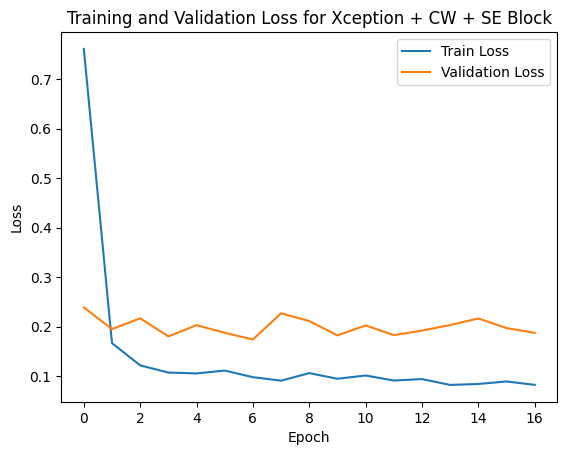

In [11]:
plot_loss_curve(xception_se_train_losses, xception_se_val_losses, 'Xception + CW + SE Block')

### Model Evaluation — Xception + SE

In [12]:
evaluate_model(xception_se_model)

Accuracy:  95.04%
Precision: 0.9549
Recall:    0.9504
F1 Score:  0.9506


### XAI — Xception + SE

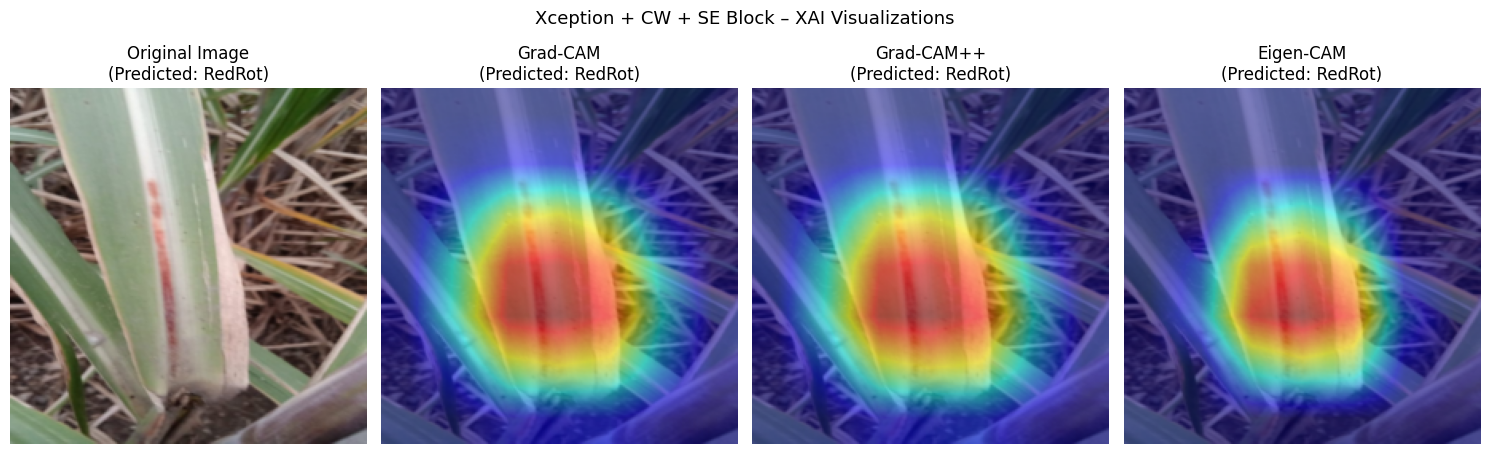

In [13]:
# Target layer: attention module output (last meaningful conv feature map)
run_xai(
    model       = xception_se_model,
    model_label = 'Xception + CW + SE Block',
    target_layers_fn = lambda m: [m.attention]
)

---
## Model 2: Xception + CW + CBAM Block

In [14]:
xception_cbam_model, xception_cbam_train_losses, xception_cbam_val_losses = train_attention_model(
    arch='xception', attention='cbam', num_classes=num_classes
)


 Training: XCEPTION + CW + CBAM Block


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Epoch 1/50


Train Loss: 0.7291, Validation Loss: 0.2702
Epoch 2/50


Train Loss: 0.1687, Validation Loss: 0.1993
Epoch 3/50


...

Train Loss: 0.0946, Validation Loss: 0.1856
Epoch 16/50


Train Loss: 0.1007, Validation Loss: 0.2309
Epoch 17/50


Train Loss: 0.1011, Validation Loss: 0.2093
Epoch 18/50


Train Loss: 0.0898, Validation Loss: 0.1792
Epoch 19/50


Train Loss: 0.0835, Validation Loss: 0.1887
Early stopping triggered.
Model saved as 'transfer_learning_xception_cbam.h5'
Model saved as 'transfer_learning_xception_cbam.pth' and 'transfer_learning_xception_cbam.h5'


### Loss Curve — Xception + CBAM

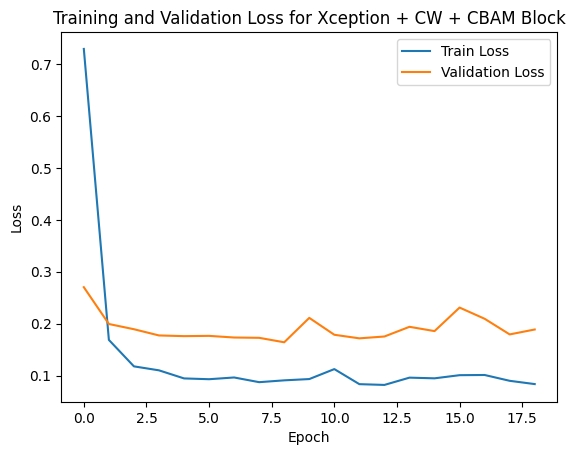

In [15]:
plot_loss_curve(xception_cbam_train_losses, xception_cbam_val_losses, 'Xception + CW + CBAM Block')

### Model Evaluation — Xception + CBAM

In [16]:
evaluate_model(xception_cbam_model)

Accuracy:  94.50%
Precision: 0.9469
Recall:    0.9450
F1 Score:  0.9453


### XAI — Xception + CBAM

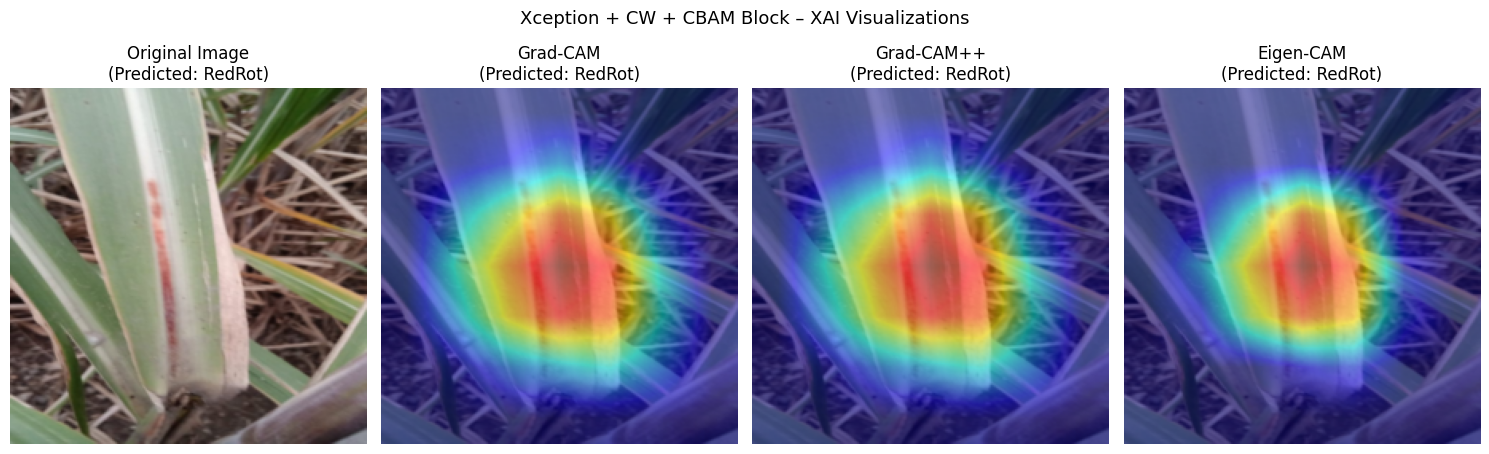

In [17]:
run_xai(
    model       = xception_cbam_model,
    model_label = 'Xception + CW + CBAM Block',
    target_layers_fn = lambda m: [m.attention.spatial_attention]
)

---
## Model 3: InceptionV3 + CW + SE Block

In [18]:
inception_se_model, inception_se_train_losses, inception_se_val_losses = train_attention_model(
    arch='inception_v3', attention='se', num_classes=num_classes
)


 Training: INCEPTION_V3 + CW + SE Block
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 179MB/s]


Epoch 1/50


Train Loss: 0.8010, Validation Loss: 0.2841
Epoch 2/50


Train Loss: 0.2336, Validation Loss: 0.2093
Epoch 3/50


...

Train Loss: 0.1223, Validation Loss: 0.2070
Epoch 20/50


Train Loss: 0.1048, Validation Loss: 0.2086
Epoch 21/50


Train Loss: 0.1091, Validation Loss: 0.2279
Epoch 22/50


Train Loss: 0.1168, Validation Loss: 0.1951
Epoch 23/50


Train Loss: 0.1216, Validation Loss: 0.1989
Early stopping triggered.
Model saved as 'transfer_learning_inception_v3_se.h5'
Model saved as 'transfer_learning_inception_v3_se.pth' and 'transfer_learning_inception_v3_se.h5'


### Loss Curve — InceptionV3 + SE

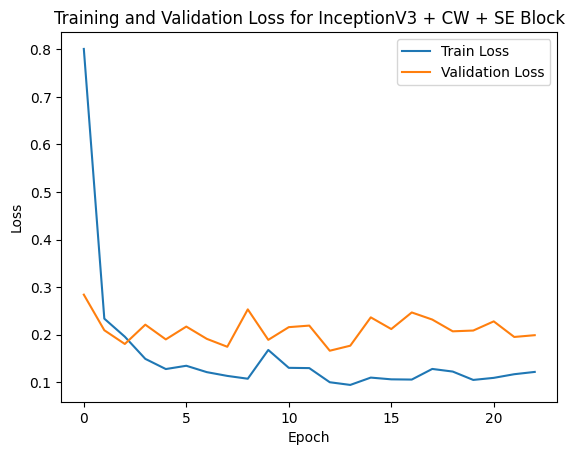

In [19]:
plot_loss_curve(inception_se_train_losses, inception_se_val_losses, 'InceptionV3 + CW + SE Block')

### Model Evaluation — InceptionV3 + SE

In [20]:
evaluate_model(inception_se_model)

Accuracy:  94.07%
Precision: 0.9438
Recall:    0.9407
F1 Score:  0.9416


### XAI — InceptionV3 + SE

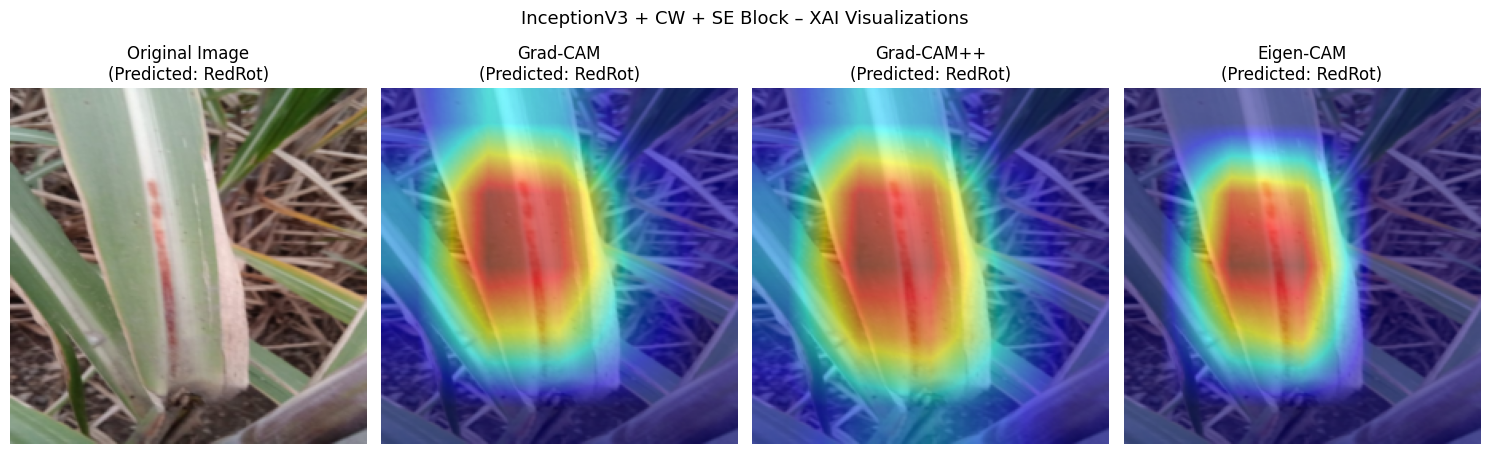

In [21]:
run_xai(
    model       = inception_se_model,
    model_label = 'InceptionV3 + CW + SE Block',
    target_layers_fn = lambda m: [m.inception_blocks[-1]]
)

---
## Model 4: InceptionV3 + CW + CBAM Block

In [22]:
inception_cbam_model, inception_cbam_train_losses, inception_cbam_val_losses = train_attention_model(
    arch='inception_v3', attention='cbam', num_classes=num_classes
)


 Training: INCEPTION_V3 + CW + CBAM Block
Epoch 1/50


Train Loss: 0.8266, Validation Loss: 0.3127
Epoch 2/50


Train Loss: 0.2416, Validation Loss: 0.2684
Epoch 3/50


Train Loss: 0.1646, Validation Loss: 0.1811
Epoch 4/50


Train Loss: 0.1595, Validation Loss: 0.1936
Epoch 5/50


...

Train Loss: 0.0919, Validation Loss: 0.2192
Epoch 24/50


Train Loss: 0.1117, Validation Loss: 0.2465
Epoch 25/50


Train Loss: 0.1476, Validation Loss: 0.1777
Epoch 26/50


Train Loss: 0.1135, Validation Loss: 0.1668
Epoch 27/50


Train Loss: 0.0960, Validation Loss: 0.1564
Early stopping triggered.
Model saved as 'transfer_learning_inception_v3_cbam.h5'
Model saved as 'transfer_learning_inception_v3_cbam.pth' and 'transfer_learning_inception_v3_cbam.h5'


### Loss Curve — InceptionV3 + CBAM

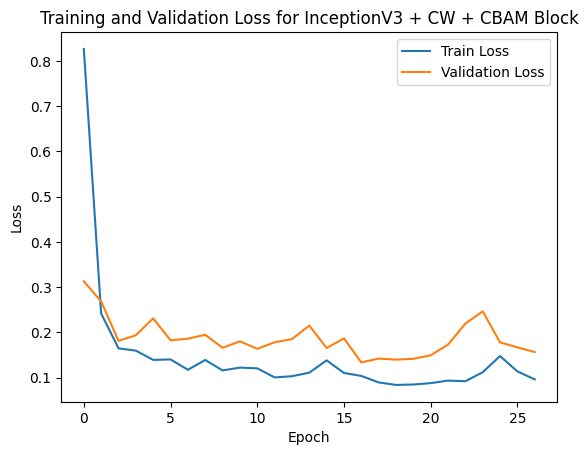

In [23]:
plot_loss_curve(inception_cbam_train_losses, inception_cbam_val_losses, 'InceptionV3 + CW + CBAM Block')

### Model Evaluation — InceptionV3 + CBAM

In [24]:
evaluate_model(inception_cbam_model)

Accuracy:  95.15%
Precision: 0.9534
Recall:    0.9515
F1 Score:  0.9520


### XAI — InceptionV3 + CBAM

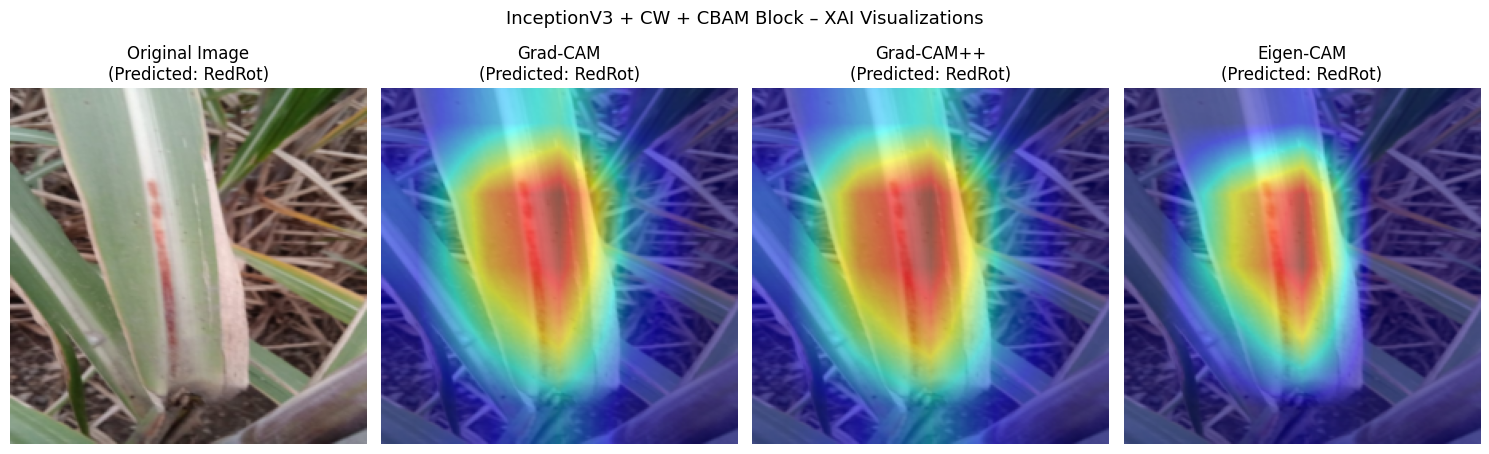

In [25]:
run_xai(
    model       = inception_cbam_model,
    model_label = 'InceptionV3 + CW + CBAM Block',
    target_layers_fn = lambda m: [m.inception_blocks[-1]]
)